In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('breast_cancer_logistic_vif_rfe_dataset.csv')
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [3]:
#check for nulls
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [4]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


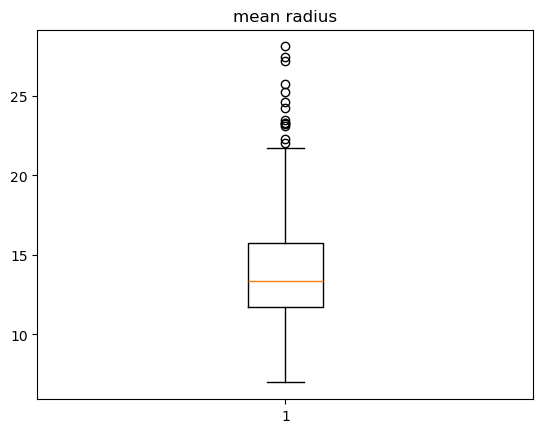

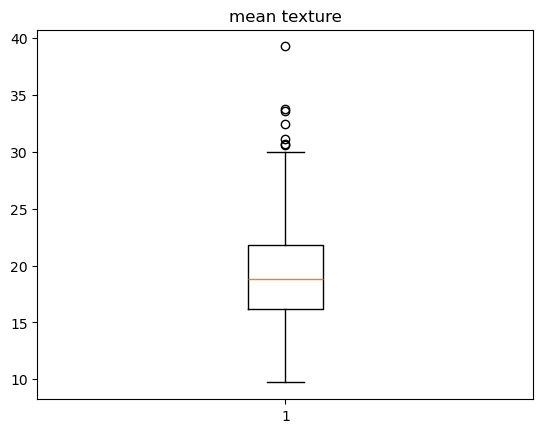

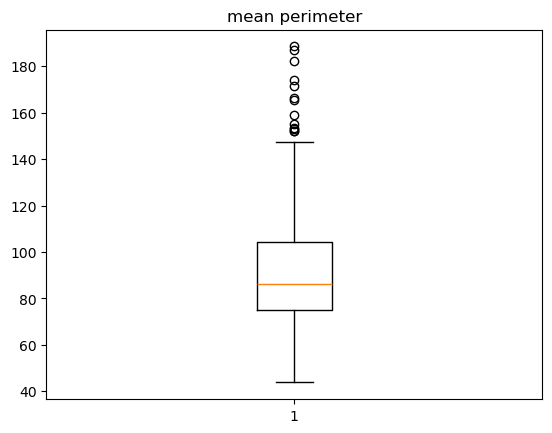

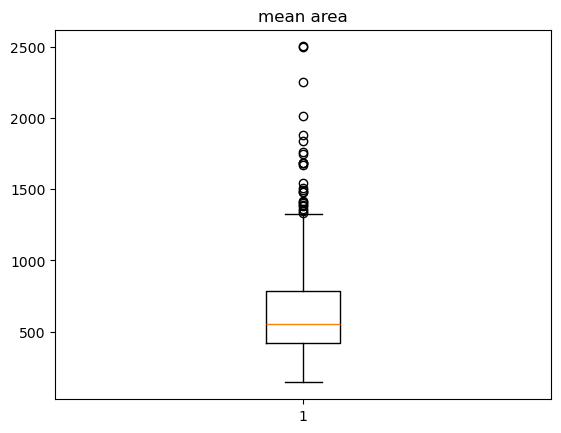

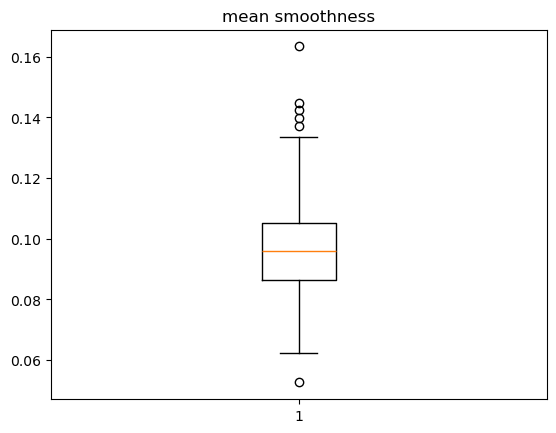

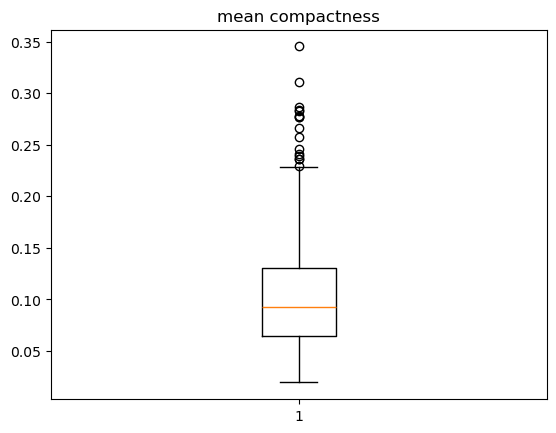

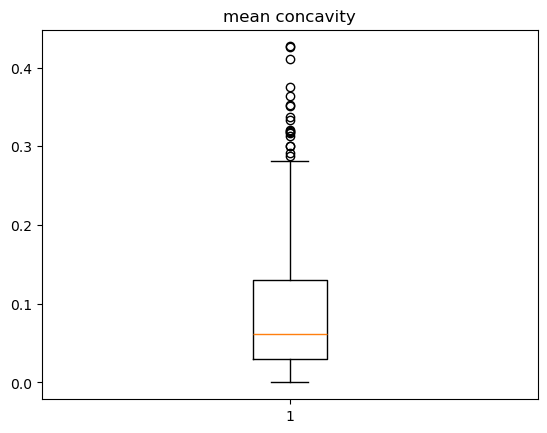

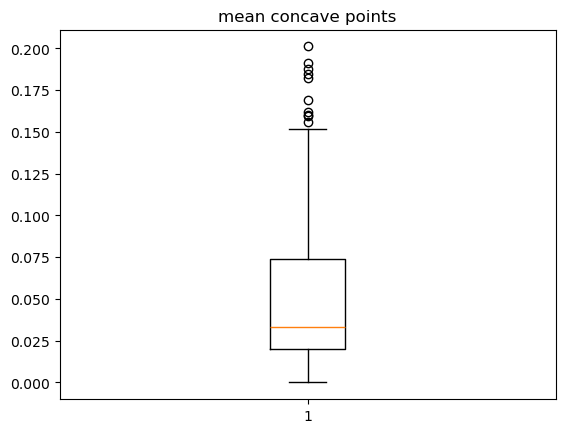

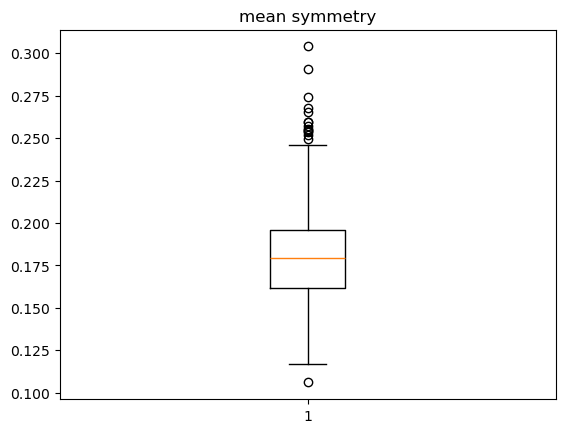

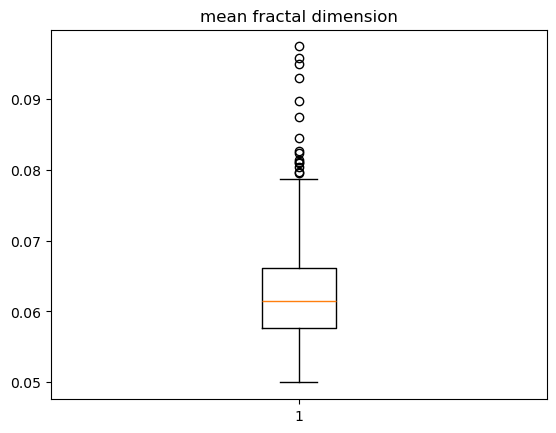

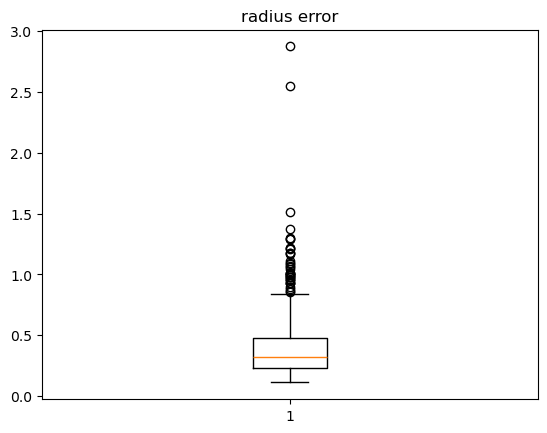

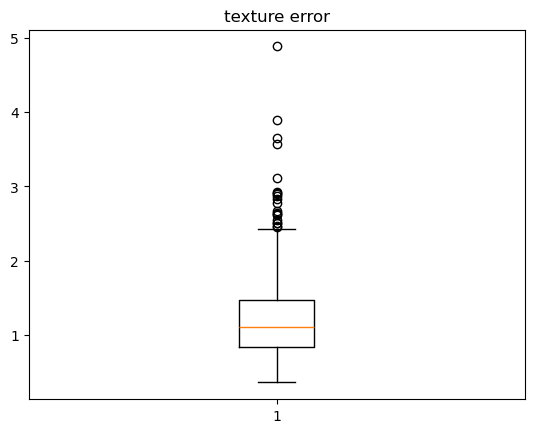

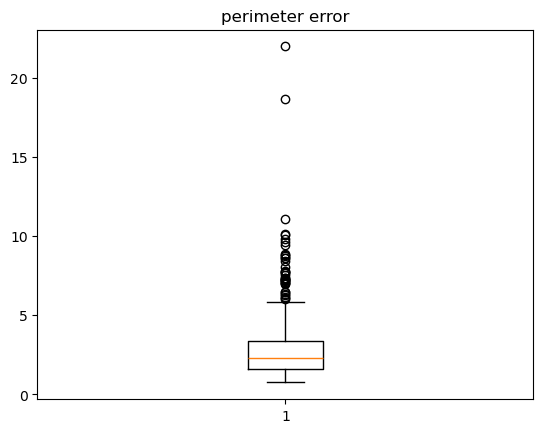

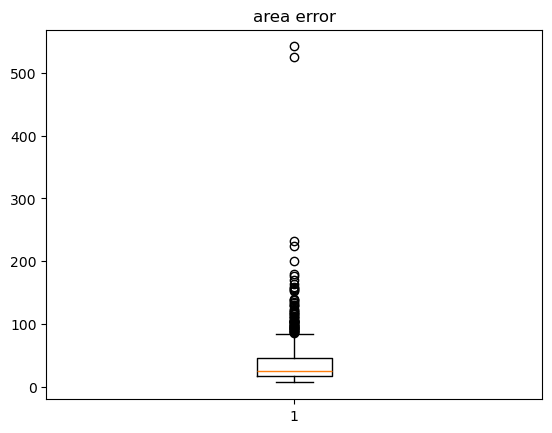

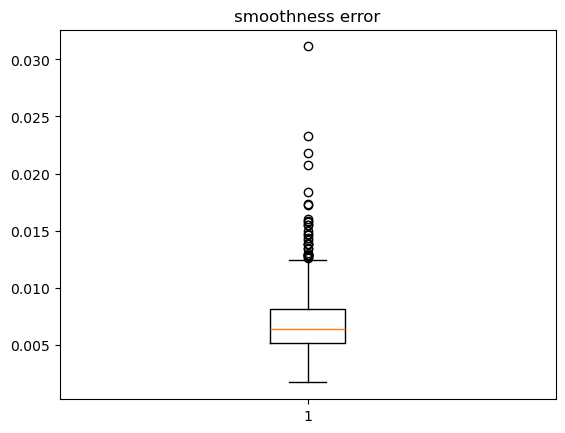

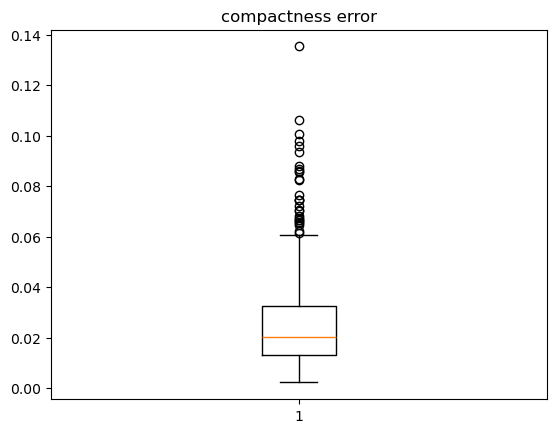

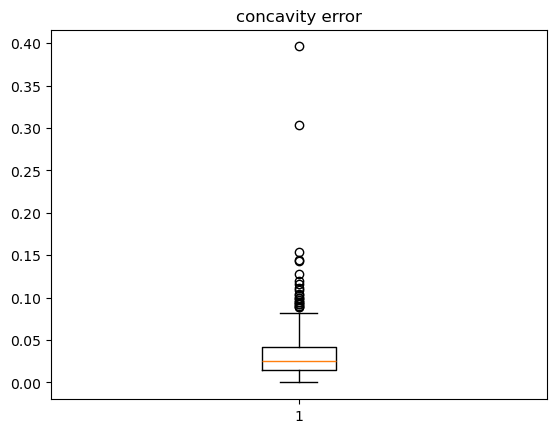

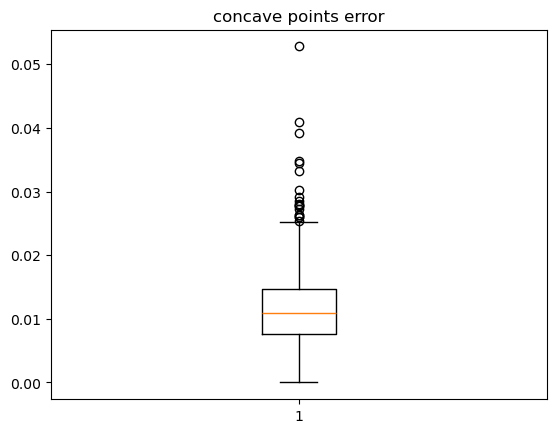

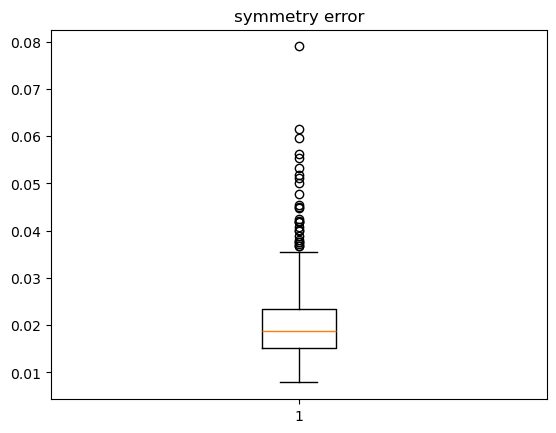

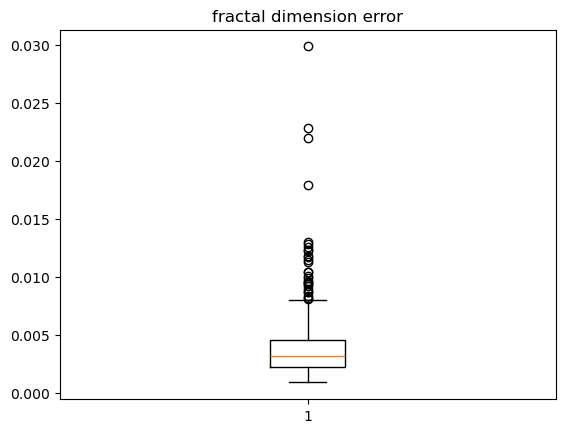

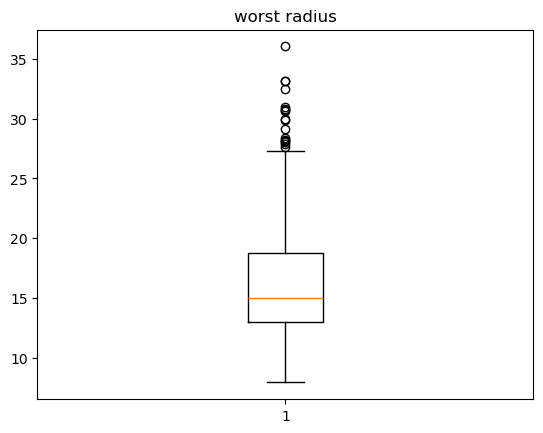

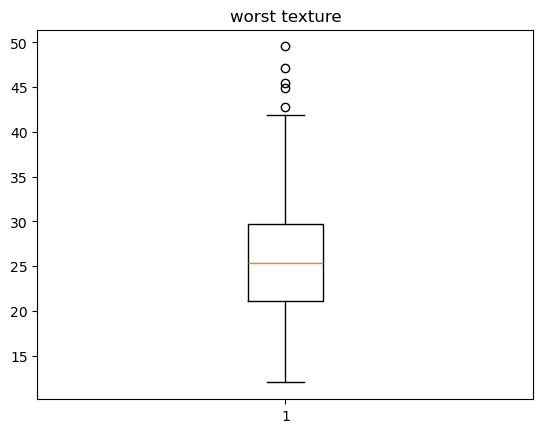

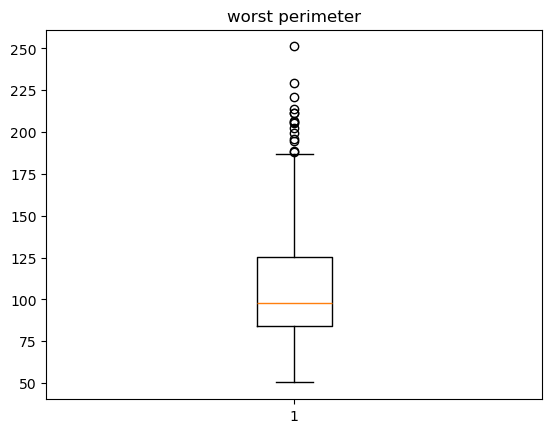

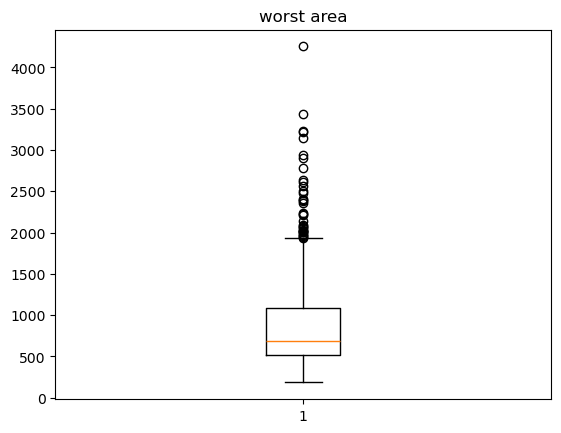

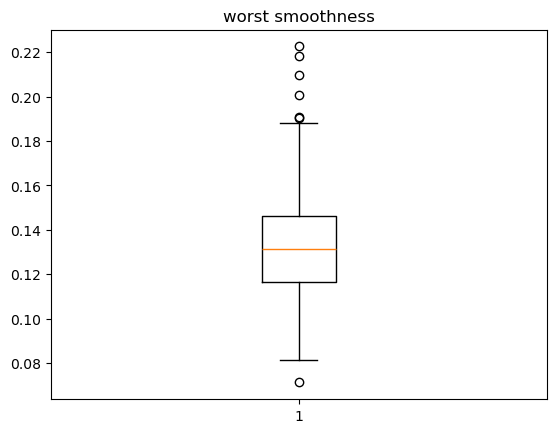

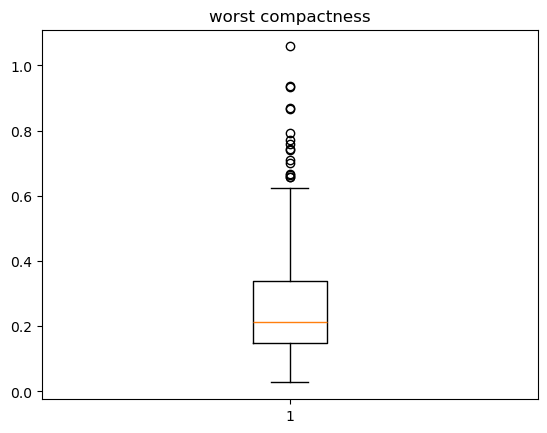

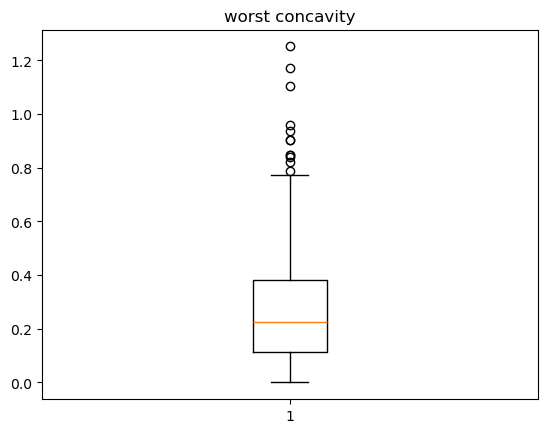

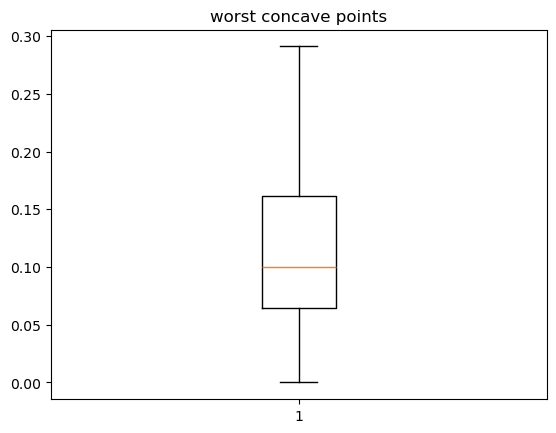

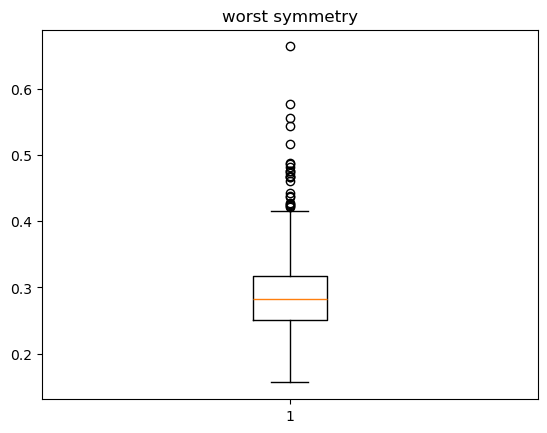

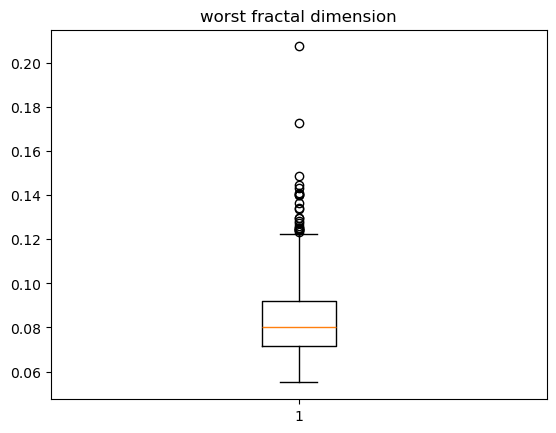

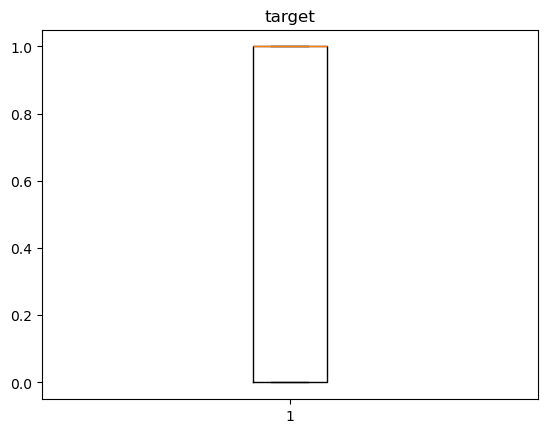

In [7]:
#Check for outliers
for i in df.columns:
    if df[i].dtypes != 'object':
        plt.boxplot(df[i])
        plt.title(i)
        plt.show()

In [8]:
#Ignore the Label encoding part if all the columns are of float or int.

In [9]:
#Recursive feature elimination (RFE)
x= df.iloc[:,:-1]
y= df['target']

In [10]:
x

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [11]:
y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

In [12]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [13]:
from sklearn.feature_selection import RFE
#Apply rfe
rfe=RFE(model)
rfe.fit(x,y)

C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing

,estimator,LogisticRegression()
,n_features_to_select,None
,step,1
,verbose,0
,importance_getter,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


In [14]:
#RFE will give the index of the columns that are important
rfe.support_  #support_ will give you a boolean list in which wherever you are having True means that column is imp

array([ True,  True, False, False, False,  True,  True,  True,  True,
       False,  True,  True,  True, False, False, False, False, False,
       False, False,  True,  True, False, False, False,  True,  True,
        True, False,  True])

In [15]:
imp_index_col=[i for i,data in enumerate(rfe.support_) if data==True]

In [17]:
column_name=x.columns
imp_cols=[column_name[i] for i in imp_index_col]
imp_cols

['mean radius',
 'mean texture',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'radius error',
 'texture error',
 'perimeter error',
 'worst radius',
 'worst texture',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst fractal dimension']

In [18]:
x=x.loc[:,['mean radius',
 'mean perimeter',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'radius error',
 'texture error',
 'perimeter error',
 'worst radius',
 'worst texture',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry']]
y=df['target']

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.20,random_state = 42)

In [20]:
x_train

,mean radius,mean perimeter,mean compactness,mean concavity,mean concave points,mean symmetry,radius error,texture error,perimeter error,worst radius,worst texture,worst compactness,worst concavity,worst concave points,worst symmetry
68,9.029,58.79,0.14130,0.31300,0.04375,0.2111,0.3274,1.1940,1.8850,10.310,22.65,0.43650,1.25200,0.17500,0.4228
181,21.090,142.70,0.28320,0.24870,0.14960,0.2395,0.6298,0.7629,4.4140,26.680,33.48,0.75840,0.67800,0.29030,0.4098
63,9.173,59.20,0.08751,0.05988,0.02180,0.2341,0.4098,2.2650,2.6080,10.010,19.23,0.16780,0.13970,0.05087,0.3282
248,10.650,68.01,0.07234,0.02379,0.01615,0.1897,0.2497,1.4930,1.4970,12.250,35.19,0.13980,0.11250,0.06136,0.3409
60,10.170,64.55,0.08061,0.01084,0.01290,0.2743,0.5158,1.4410,3.3120,11.020,17.45,0.09866,0.02168,0.02579,0.3557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,58.79,0.15310,0.08606,0.02872,0.1902,0.5262,0.8522,3.1680,9.733,15.67,0.24360,0.14340,0.04786,0.2254
106,11.640,75.17,0.10170,0.07070,0.03485,0.1801,0.3060,1.6570,2.1550,13.140,29.26,0.26600,0.28730,0.12180,0.2806
270,14.290,90.30,0.02675,0.00725,0.00625,0.1508,0.1302,0.7198,0.8439,14.910,20.65,0.05036,0.03866,0.03333,0.2458
435,13.980,91.12,0.11330,0.11260,0.06463,0.1669,0.2208,0.9533,1.6020,17.040,30.80,0.35680,0.40690,0.18270,0.3179


In [21]:
x_test

,mean radius,mean perimeter,mean compactness,mean concavity,mean concave points,mean symmetry,radius error,texture error,perimeter error,worst radius,worst texture,worst compactness,worst concavity,worst concave points,worst symmetry
204,12.47,81.09,0.10580,0.08005,0.03821,0.1925,0.3961,1.0440,2.497,14.97,24.64,0.2378,0.2671,0.10150,0.3014
70,18.94,123.60,0.10290,0.10800,0.07951,0.1582,0.7888,0.7975,5.486,24.86,26.58,0.2336,0.2687,0.17890,0.2551
131,15.46,101.70,0.12230,0.14660,0.08087,0.1931,0.4743,0.7859,3.094,19.26,26.00,0.2394,0.3791,0.15140,0.2837
431,12.40,81.47,0.13160,0.07741,0.02799,0.1811,0.1767,1.4600,2.204,12.88,22.91,0.2629,0.2403,0.07370,0.2556
540,11.54,74.65,0.11200,0.06737,0.02594,0.1818,0.2784,1.7680,1.628,12.26,19.68,0.2118,0.1797,0.06918,0.2329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,14.64,94.21,0.06698,0.05192,0.02791,0.1409,0.2204,1.0060,1.471,16.46,25.44,0.2070,0.2437,0.07828,0.2455
75,16.07,104.10,0.08424,0.09769,0.06638,0.1798,0.7474,1.0160,5.029,19.77,24.56,0.2045,0.2829,0.15200,0.2650
249,11.52,73.87,0.07808,0.04328,0.02929,0.1883,0.2562,1.0380,1.686,12.65,21.19,0.1582,0.1804,0.09608,0.2664
238,14.22,92.55,0.10390,0.11030,0.04408,0.1342,0.3354,2.3240,2.105,15.75,40.54,0.2426,0.3064,0.08219,0.1890


In [22]:
y_train

68     1
181    0
63     1
248    1
60     1
      ..
71     1
106    1
270    1
435    0
102    1
Name: target, Length: 455, dtype: int64

In [23]:
y_test

204    1
70     0
131    0
431    1
540    1
      ..
486    1
75     0
249    1
238    1
265    0
Name: target, Length: 114, dtype: int64

In [24]:
#test the model
model.fit(x_train,y_train)
#predict to test the model. Test the model
y_pred = model.predict(x_test)
y_pred

C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [25]:
#Evaluate the Model
#For a Binary Classification Problem:

 #Accuracy Score - (TP+TN)/(TP+TN+FP+FN) - TP: True Positive, TN: True Negative, FP: False Positive, FN: False negative
 #Precision Score - Out of all positives, how many were actually positive TP/(TP+FP)
 #Recall Score- Out of all positives, how many were actually predicted by the model TP/(TP+FN)
 #Confusion Matrix

from sklearn.metrics import *

In [26]:
cm = confusion_matrix(y_test,y_pred) #output format [[TN,FP],[FN,TP]]

In [27]:
cm

array([[39,  4],
       [ 1, 70]])

In [28]:
#Accuracy score
accuracy_score = (cm[0][0]+cm[1][1])/(cm[0][1] + cm[0][0] + cm[1][1] + cm[1][0])*100
accuracy_score

np.float64(95.6140350877193)

In [29]:
#Precision score
precision_score = cm[1][1]/(cm[0][1] + cm[1][1])*100
precision_score

np.float64(94.5945945945946)

In [30]:
#Recall score
recall_score = cm[1][1]/(cm[1][0] + cm[1][1])*100
recall_score

np.float64(98.59154929577466)

In [31]:
from sklearn.metrics import *

In [32]:
accuracy_score(y_test,y_pred)

0.956140350877193

In [33]:
precision_score(y_test,y_pred)

0.9459459459459459

In [34]:
recall_score(y_test,y_pred)

0.9859154929577465